# Accident Detection using CNN

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from keras import backend as K
from keras.layers import Input, Dense, Conv2D, Conv2DTranspose, Flatten, Lambda, Reshape
from keras.losses import binary_crossentropy
from imutils import paths
from tensorflow.keras.utils import img_to_array
from sklearn.model_selection import train_test_split
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from tensorflow.keras.layers import Conv2D, Activation, BatchNormalization, MaxPooling2D, Dropout, GlobalAveragePooling1D
from keras.models import Sequential
from google.colab.patches import cv2_imshow
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import random
from PIL import Image

In [ ]:
from google.colab import files
files.upload()

!ls -lha kaggle.json
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!pwd
!chmod 600 /root/.kaggle/kaggle.json

Saving kaggle.json to kaggle (2).json
-rw-r--r-- 1 root root 74 Apr 19 14:05 kaggle.json
/content


## Data Download and Extraction

Here, the `kaggle.json` file is used to authenticate and download the dataset from Kaggle. The downloaded zip file is then extracted to the `/content/` directory.

In [ ]:
!kaggle datasets download -d ckay16/accident-detection-from-cctv-footage

!unzip /content/accident-detection-from-cctv-footage.zip -d .

Dataset URL: https://www.kaggle.com/datasets/ckay16/accident-detection-from-cctv-footage
License(s): ODbL-1.0
accident-detection-from-cctv-footage.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  /content/accident-detection-from-cctv-footage.zip
replace ./data/test/Accident/acc1 (7).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


## Displaying Sample Images

This section defines a utility function `display_images` to visualize a random sample of images from the dataset, providing an initial look at the data.

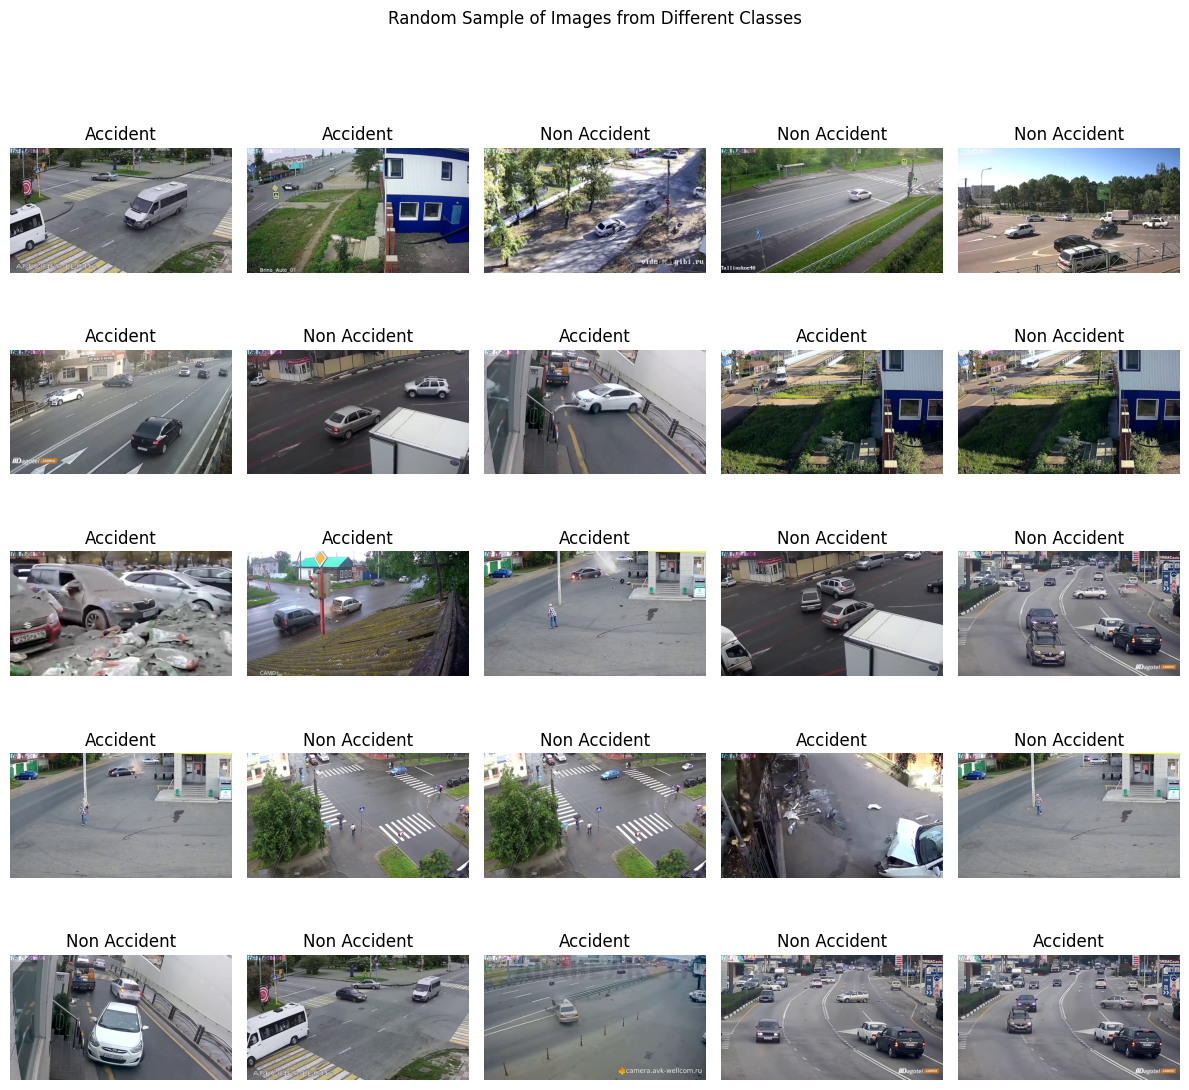

In [ ]:
imagePaths = list(paths.list_images("/content/data/train"))

def display_images(image_paths, title, cols=5, num_images=25):
  random.shuffle(image_paths)
  num_images = min(len(image_paths), num_images)
  rows = (num_images + cols - 1) // cols

  plt.figure(figsize=(12, 12))
  plt.suptitle(title)

  for i, image_path in enumerate(image_paths[:num_images]):
    plt.subplot(rows, cols, i + 1)
    img = Image.open(image_path)

    img = img.convert('RGB')
    plt.imshow(img)
    plt.title(image_path.split(os.path.sep)[4])
    plt.axis('off')

  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
  plt.show()

display_images(imagePaths, "Random Sample of Images from Different Classes", num_images=25)

## Custom Data Loaders and Preprocessors

These classes are designed to efficiently load and preprocess images for the CNN model.
- `SimpleDatasetLoader`: Loads images from specified paths and applies preprocessors.
- `SimplePreprocessor`: Resizes images to a uniform width and height.
- `ImageToArrayPreprocessor`: Converts image data into a Keras-compatible array format.

In [ ]:
class SimpleDatasetLoader:
  def __init__(self, preprocessors=None):
    self.preprocessors = preprocessors
    if self.preprocessors is None:
      self.preprocessors = []
  def load(self, imagePaths, verbose=-1):
    data = []
    labels = []

    for (i, imagePath) in enumerate(imagePaths):
      image = cv2.imread(imagePath)
      image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
      label = imagePath.split(os.path.sep)[-2]

      if self.preprocessors is not None:
        for p in self.preprocessors:
          image = p.preprocess(image)

      data.append(image)
      labels.append(label)

      if verbose > 0 and i > 0 and (i + 1) % verbose == 0:
        print("[INFO] processed {}/{}".format(i + 1, len(imagePaths)))

    return (np.array(data), np.array(labels))

In [ ]:
class SimplePreprocessor:
  def __init__(self, width, height, inter=cv2.INTER_AREA):
    self.width = width
    self.height = height
    self.inter = inter

  def preprocess(self, image):
    return cv2.resize(image, (self.width, self.height), interpolation=self.inter)

In [ ]:
class ImageToArrayPreprocessor:
  def __init__(self, dataFormat=None):
    # store the image data format
    self.dataFormat = dataFormat

  def preprocess(self, image):
    return img_to_array(image, data_format=self.dataFormat)

In [ ]:
sp = SimplePreprocessor(128, 128)
iap = ImageToArrayPreprocessor()

## Loading Training Data

This cell loads the image paths for the training dataset and initializes the `SimplePreprocessor` and `ImageToArrayPreprocessor` for data preparation. The `classNames` are also extracted.

In [ ]:
train_paths = list(paths.list_images("/content/data/train"))
val_paths = list(paths.list_images("/content/data/val"))
train_imagepaths = train_paths+val_paths
classNames = [pt.split(os.path.sep)[-2] for pt in train_imagepaths]
classNames = [str(x) for x in np.unique(classNames)]
classNames

['Accident', 'Non Accident']

# Visualize train image

### Visualizing a Sample Training Image

This cell displays a sample image from the training dataset to verify the image loading process.

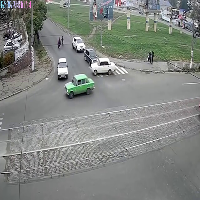

In [ ]:
img_read = cv2.imread(train_imagepaths[0])
img_read = cv2.resize(img_read, (200, 200))
cv2_imshow(img_read)

In [ ]:
sdl = SimpleDatasetLoader(preprocessors=[sp, iap])
(train_data, train_label) = sdl.load(train_imagepaths, verbose=500)
train_data = train_data.astype("float32") / 255.

[INFO] processed 500/889


## Loading Validation Data

Similar to the training data, this section loads image paths for the validation dataset and prepares it using the defined preprocessors.

In [ ]:
validation_imagepaths = list(paths.list_images("/content/data/test"))
classNames = [pt.split(os.path.sep)[-2] for pt in validation_imagepaths]
classNames = [str(x) for x in np.unique(classNames)]
classNames

['Accident', 'Non Accident']

# Visualize validation image

### Visualizing a Sample Validation Image

This cell displays a sample image from the validation dataset.

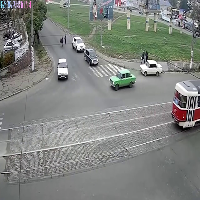

In [ ]:
img_read = cv2.imread(validation_imagepaths[50])
img_resize = cv2.resize(img_read, (200, 200))
cv2_imshow(img_resize)

In [ ]:
sdl = SimpleDatasetLoader(preprocessors=[sp, iap])
(validation_data, validation_label) = sdl.load(validation_imagepaths, verbose=10)
validation_data = validation_data.astype("float32") / 255.

[INFO] processed 10/100
[INFO] processed 20/100
[INFO] processed 30/100
[INFO] processed 40/100
[INFO] processed 50/100
[INFO] processed 60/100
[INFO] processed 70/100
[INFO] processed 80/100
[INFO] processed 90/100
[INFO] processed 100/100


## Image Preprocessing Demonstration

This section demonstrates the effect of `SimplePreprocessor` on an image, showing the original image and its resized version.

original image shape (576, 720, 3)
preprocessed image shape (128, 128, 3)


<function matplotlib.pyplot.show(close=None, block=None)>

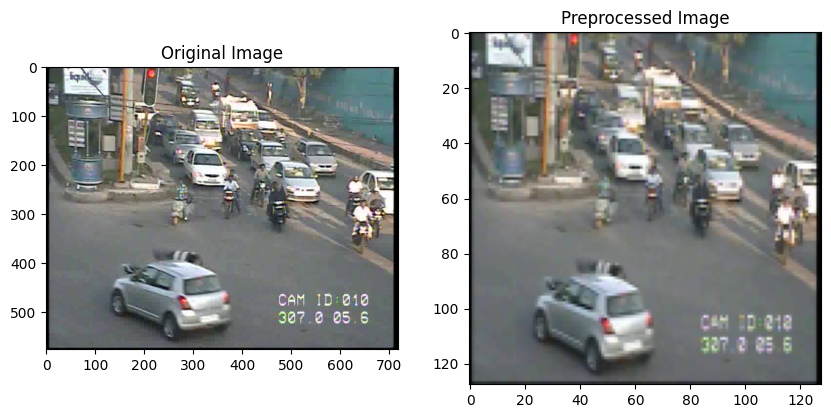

In [ ]:
image_path = '/content/data/train/Accident/acc1 (2).jpg'
image = cv2.imread(image_path)
print("original image shape", image.shape)
preprocessor = SimplePreprocessor(128, 128)


preprocessed_image = preprocessor.preprocess(image)
print("preprocessed image shape", preprocessed_image.shape)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(preprocessed_image, cv2.COLOR_BGR2RGB))
plt.title("Preprocessed Image")

plt.show

## Label Encoding and One-Hot Encoding

The image labels (e.g., 'Accident', 'Non Accident') are converted into numerical format using `LabelEncoder` and then into a one-hot encoded format suitable for neural network training.

In [ ]:
le = LabelEncoder()
le.fit(train_label)
train_labels = le.transform(train_label)
train_labels = to_categorical(train_labels)

In [ ]:
le.fit(validation_label)
validation_labels = le.transform(validation_label)
validation_labels = to_categorical(validation_labels)
#

## Data Distribution Visualization

These cells visualize the distribution of training and validation samples, both as a bar chart and a pie chart, to ensure a balanced split.

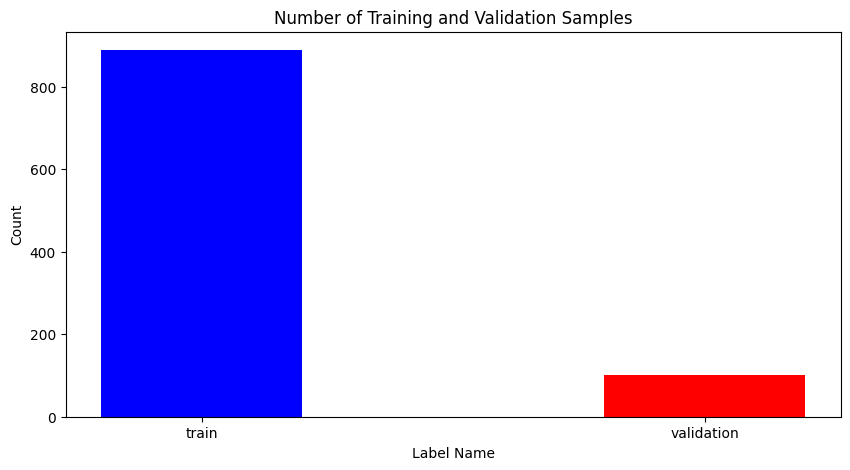

In [ ]:
train_count = train_labels.shape[0]
validation_count = validation_labels.shape[0]
counts = [train_count, validation_count]
fig = plt.figure(figsize=(10, 5))
label_name = ['train', 'validation']
plt.bar(label_name, counts, color=["blue", "red"], width=0.4)
plt.xlabel("Label Name")
plt.ylabel("Count")
plt.title("Number of Training and Validation Samples")
plt.show()

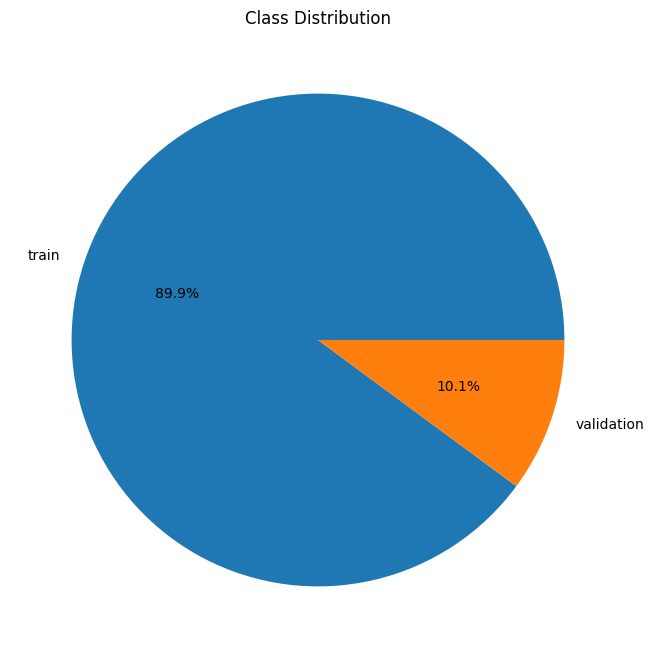

In [ ]:
import pandas as pd
train_count = train_labels.shape[0]
validation_count = validation_labels.shape[0]
label_counts = {'train': train_count, 'validation': validation_count}
df_counts = pd.DataFrame(label_counts.items(), columns=['Label', 'Count'])
plt.figure(figsize = (8, 8))
plt.pie(df_counts['Count'], labels=df_counts['Label'], autopct='%1.1f%%')
plt.title('Class Distribution')
plt.show()
#

## Convolutional Neural Network (CNN) Model Architecture

This section defines the architecture of the CNN model. It includes multiple `Conv2D` layers for feature extraction, `BatchNormalization` for stable training, `MaxPooling2D` for dimensionality reduction, `Flatten` to prepare for dense layers, and `Dense` layers for classification. Dropout layers are included to prevent overfitting.

# Training using Convolution Neural Network (CNN Model)

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Flatten, Dense, Dropout
from keras.callbacks import ModelCheckpoint
input_shape = (128, 128, 1)
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu',padding = 'Same', input_shape=input_shape))
model.add(BatchNormalization())

model.add(Conv2D(32, kernel_size=(3, 3), activation='relu',padding = 'Same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu',padding = 'Same'))
model.add(BatchNormalization())

model.add(Conv2D(64, (3, 3), activation='relu',padding = 'Same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, kernel_size=(3, 3), activation='relu',padding = 'Same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu',padding = 'Same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))


model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation='softmax'))
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           13

 Total params: 1,345,314 (5.13 MB)

 Trainable params: 1,344,418 (5.13 MB)

 Non-trainable params: 896 (3.50 KB)

## Model Training Setup and Execution

This section prepares the directory for saving model weights, configures the `ModelCheckpoint` callback to save the best model based on validation accuracy, sets up the Adam optimizer, and compiles the model. Finally, the model is trained on the preprocessed data.

In [ ]:
if not os.path.exists("/content/drive/MyDrive/accident_detection"):
  os.mkdir("/content/drive/MyDrive/accident_detection")

In [ ]:
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/accident_detection/car_accident_model.weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    mode='max',
    verbose=1
    )

optimizer = Adam(learning_rate=0.001)

model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

print("[INFO] training model...")
H = model.fit(train_data, train_labels, batch_size=16, validation_data=(validation_data, validation_labels), epochs=100, callbacks=[checkpoint])

[INFO] training model...
Epoch 1/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.8806 - loss: 0.2064
Epoch 1: val_accuracy improved from None to 0.86000, saving model to /content/drive/MyDrive/accident_detection/car_accident_model.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/accident_detection/car_accident_model.weights.h5
56/56 ━━━━━━━━━━━━━━━━━━━━ 22s 177ms/step - accuracy: 0.8729 - loss: 0.2200 - val_accuracy: 0.8600 - val_loss: 0.2779
Epoch 2/100
54/56 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8867 - loss: 0.2089
Epoch 2: val_accuracy did not improve from 0.86000
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8886 - loss: 0.2078 - val_accuracy: 0.8000 - val_loss: 0.3761
Epoch 3/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9020 - loss: 0.2118
Epoch 3: val_accuracy did not improve from 0.86000
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8864 - loss: 0.2369 - val_accuracy: 0.8300 - val_loss: 0.3344
Epoch 4/100
54/5

## Model Prediction on Validation Data

After training, the best model weights are loaded, and predictions are made on the validation dataset to evaluate its performance.

In [ ]:
model.load_weights("/content/drive/MyDrive/accident_detection/car_accident_model.weights.h5")
prediction = model.predict(validation_data)

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 238ms/step


In [ ]:
prediction

array([[3.3096859e-12, 1.0000000e+00],
       [3.6884523e-10, 1.0000000e+00],
       [3.3784832e-29, 1.0000000e+00],
       [9.6784003e-09, 1.0000000e+00],
       [6.6467343e-10, 1.0000000e+00],
       [1.2424127e-17, 1.0000000e+00],
       [5.1993063e-15, 1.0000000e+00],
       [7.8813418e-09, 1.0000000e+00],
       [2.5849941e-13, 1.0000000e+00],
       [8.3518009e-10, 1.0000000e+00],
       [6.6377664e-17, 1.0000000e+00],
       [1.5895555e-09, 1.0000000e+00],
       [1.4849593e-05, 9.9998510e-01],
       [1.7896559e-08, 1.0000000e+00],
       [4.4665504e-15, 1.0000000e+00],
       [1.1699300e-06, 9.9999881e-01],
       [2.5414884e-09, 1.0000000e+00],
       [2.0790067e-06, 9.9999797e-01],
       [5.9606773e-09, 1.0000000e+00],
       [8.5521090e-10, 1.0000000e+00],
       [9.0983088e-10, 1.0000000e+00],
       [2.3096229e-06, 9.9999774e-01],
       [4.2355632e-29, 1.0000000e+00],
       [1.3377341e-08, 1.0000000e+00],
       [1.2464219e-13, 1.0000000e+00],
       [2.5581724e-06, 9.

## Classification Report

This cell generates a detailed classification report, including precision, recall, and F1-score for each class, providing a comprehensive evaluation of the model's performance.

# Classification Report

In [ ]:
classNames = ['Accident', 'Not Accident']
print(classification_report(validation_labels.argmax(axis=1), prediction.argmax(axis=1), target_names=classNames))

              precision    recall  f1-score   support

    Accident       1.00      0.96      0.98        47
Not Accident       0.96      1.00      0.98        53

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



## Confusion Matrix

This cell visualizes the confusion matrix, which shows the number of correct and incorrect predictions made by the model for each class, helping to understand where the model might be making errors.

# Confusuion Matrix

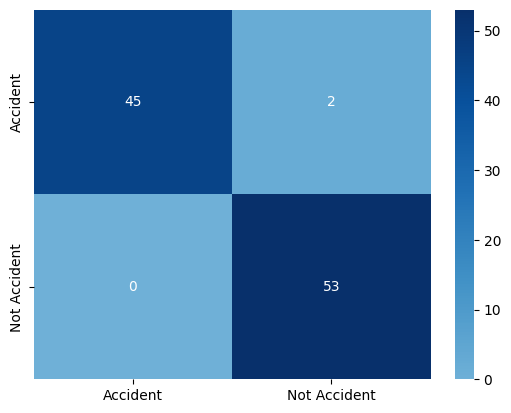

In [ ]:
import seaborn as sns
CM = confusion_matrix(validation_labels.argmax(axis=1), prediction.argmax(axis=1))

sns.heatmap(CM, center = True, annot=True, fmt='d', cmap="Blues", xticklabels=classNames, yticklabels=classNames)
plt.show()

## Single Image Prediction

This section demonstrates how to use the trained model to predict whether a single, new image contains an 'Accident' or 'Not Accident'. The image is loaded, preprocessed, and then passed to the model for inference. The predicted class is printed, and the image is displayed.

# Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
predicted class is:  Not Accident


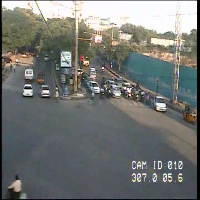

In [ ]:
image_path = "/content/data/train/Non Accident/5_17.jpg"
image = cv2.imread(image_path)
gray_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
sp = SimplePreprocessor(128, 128)
data = sp.preprocess(gray_img)
data = data.astype("float") / 255.0
data = np.expand_dims(data, axis=0)
data = np.expand_dims(data, axis=-1)
model.load_weights("/content/drive/MyDrive/accident_detection/car_accident_model.weights.h5")
preds = model.predict(data)
classNames = ['Accident', 'Not Accident']
print("predicted class is: ", classNames[preds.argmax()])
image= cv2.resize(image, (200, 200))
cv2_imshow(image)

### Saving the full model

Saving the entire model (architecture, weights, and training configuration) allows you to re-instantiate the exact same model later without needing to define the architecture again. This is useful for deployment or further training.

In [ ]:
import tensorflow as tf

# Define the path to save the full model
model_save_path = '/content/drive/MyDrive/accident_detection/car_accident_model.keras'

# Save the entire model (architecture, weights, and optimizer state)
model.save(model_save_path)
print(f"Full model saved to: {model_save_path}")

# To load the model later:
# loaded_model = tf.keras.models.load_model(model_save_path)
# print("Model loaded successfully!")

Full model saved to: /content/drive/MyDrive/accident_detection/car_accident_model.keras


### Testing CNN Kera model

After saving the keras file, I tested the CNN model to make sure its ready to be used in the project

In [ ]:
import tensorflow as tf
import numpy as np

# Load the entire model from the saved .keras file
model_save_path = '/content/drive/MyDrive/accident_detection/car_accident_model.keras'
loaded_model = tf.keras.models.load_model(model_save_path)
print("Model loaded successfully!")

# Get a sample image from the validation data for prediction
# For demonstration, let's pick the first image in validation_data
sample_image = validation_data[0:1] # Keep the batch dimension

# Make a prediction using the loaded model
predictions = loaded_model.predict(sample_image)

# Get the predicted class label
classNames = ['Accident', 'Not Accident'] # Reuse classNames from earlier
predicted_class_index = np.argmax(predictions)
predicted_class_label = classNames[predicted_class_index]

print(f"Predicted class for the sample image: {predicted_class_label}")

# You can also display the sample image if desired
# Make sure to reverse the preprocessing for display if it was grayscale
# For now, let's just show the predicted label.

Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted class for the sample image: Not Accident
